# Self-Supervised Pretraining & Fine-tuning Ablations

Reproduces the **SSL** panels of the DeepCell Types paper: the test-split **Frozen-CLS vs Pretrain + Fine-tune** metric bars (cell-type macro F1 + marker-positivity F1), and the masked-marker **pretext-task** diagnostic (does the SSL objective itself learn?).

All figures use a consistent publication figure style (via `dct_figures.style`). Scores use the v10 test split, hierarchical evaluation with per-(tissue, modality) IQR-fence cell-type abstention at **k = 0.2** (the paper headline operating point).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, json
from dct_figures import paths, style, colors, scoring
style.apply_style()

## Shared config

Layout constants + the helper draw functions used by the panels below. Cell-type ordering comes from `scoring.CT2IDX`; the panels score the prediction CSVs through `scoring.score_csv` at the headline `abstention_k=0.2`.

In [2]:
from dct_figures.style import (
    PAL, COL_1_5, COL_2, MAX_HEIGHT,
    BAR_WIDTH, BAR_WIDTH_GROUP,
    style_ax, setup_perf_bar_axes,
    PERF_BAR_INCHES, PERF_BAR_PITCH_INCHES,
    FS_AXIS_TITLE, FS_AXIS_LABEL, FS_BODY, FS_TICK, FS_SMALL, FS_TINY,
)
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch



def _rounded_box(ax, x, y, w, h, label, *, color, text_color='white',
                 fontsize=8.0, font_weight='600', linewidth=0.6):
    bbox = FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle='round,pad=0.04,rounding_size=0.18',
        facecolor=color, edgecolor=PAL['theme_dark'],
        linewidth=linewidth, zorder=3,
    )
    ax.add_patch(bbox)
    ax.text(x, y, label, ha='center', va='center', color=text_color,
            fontsize=fontsize, fontweight=font_weight, zorder=4)


def _arrow(ax, x0, y0, x1, y1, *, color=None, lw=0.9):
    color = color or PAL['dark']
    ax.add_patch(FancyArrowPatch(
        (x0, y0), (x1, y1), arrowstyle='-|>', mutation_scale=10,
        color=color, linewidth=lw, zorder=2,
    ))


def _setup_schematic_ax(ax, title):
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6.5)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(title, fontsize=FS_AXIS_TITLE, fontweight='normal', pad=2,
                 color=PAL['dark'], loc='left', x=0.0)

## Frozen-CLS vs Pretrain + Fine-tune — Fig. 3e

caption: Test-split cell-type macro F1 + MP F1 — Frozen-CLS vs Pretrain + Fine-tune (both share the SSL backbone).

Reads `ssl_ablation.csv` (self-contained: one row per condition with the `cell_type_macro_f1` and `mp_f1` columns the headline panels also use).

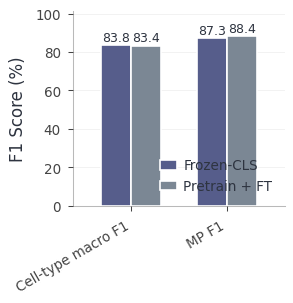

In [3]:
METRICS = [
    ('cell_type_macro_f1', 'Cell-type macro F1'),
    ('mp_f1',              'MP F1'),
]
CONDITIONS = ('scratch', 'ssl_then_ft')
COND_LABELS = {'scratch': 'Frozen-CLS', 'ssl_then_ft': 'Pretrain + FT'}

ablation = pd.read_csv(paths.need(paths.OUTPUT / 'ssl_ablation.csv')).set_index('condition')
means = {c: [float(ablation.loc[c, k]) for k, _ in METRICS] for c in CONDITIONS}

fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
x, bar_w = setup_perf_bar_axes(fig, ax, len(METRICS),
                               target_bar_inches=PERF_BAR_INCHES,
                               target_pitch_inches=2 * PERF_BAR_PITCH_INCHES)
cond_colors = [PAL['theme'], PAL['gray']]
all_vals = []
for i, cond in enumerate(CONDITIONS):
    offset = (-0.5 + i) * bar_w
    vals = np.array([means[cond][mi] for mi in range(len(METRICS))]) * 100.0
    all_vals.append(vals)
    ax.bar(x + offset, vals, width=bar_w, color=cond_colors[i],
           edgecolor='white', linewidth=0.8, zorder=3, label=COND_LABELS[cond])
    for xi, v in zip(x + offset, vals):
        if np.isfinite(v):
            ax.text(xi, v + 0.5, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=FS_SMALL, color=PAL['dark'])

ax.set_xticks(x)
ax.set_xticklabels([m[1] for m in METRICS], fontsize=FS_TICK, rotation=30, ha='right')
ax.set_ylabel('F1 Score (%)')
flat = np.concatenate(all_vals); flat = flat[np.isfinite(flat)]
ax.set_ylim(0, (flat.max() if flat.size else 1.0) * 1.15)
ax.legend(fontsize=FS_TICK, loc='lower right', frameon=False,
          handlelength=1.2, columnspacing=1.2)
style_ax(ax)
plt.show()

## Masked-marker pretext-task diagnostic — Supp. Fig. 6d

caption: Does the masked-marker pretext task itself learn? Marker-positivity macro F1 (learned per-marker thresholds, 64 markers with support; house MP metric) on a 50k-cell sample of the v10 test split. MASKED channels (marker image hidden → inferred from the other markers) reach 73.2% F1, close to the UNMASKED visible-image reference (82.7%) and far above an untrained random-init backbone (27.0%) — the SSL objective captures real cross-marker structure.

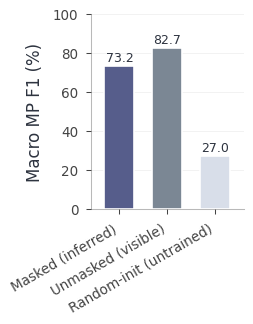

In [4]:
ORDER = ('masked', 'unmasked', 'random')
PRETEXT_COLORS = {
    'masked': PAL['theme'],
    'unmasked': PAL['gray'],
    'random': PAL['light_gray'],
}
pretext = json.load(open(paths.need(paths.OUTPUT / 'ssl_pretext_metrics.json')))
cond = pretext['conditions']

fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
x, bar_w = setup_perf_bar_axes(fig, ax, len(ORDER),
                               target_bar_inches=PERF_BAR_INCHES,
                               target_pitch_inches=PERF_BAR_PITCH_INCHES)
vals = np.array([cond[k]['macro_f1'] for k in ORDER]) * 100.0
bar_cols = [PRETEXT_COLORS[k] for k in ORDER]
ax.bar(x, vals, width=bar_w, color=bar_cols, edgecolor='white',
       linewidth=0.8, zorder=3)
for xi, v in zip(x, vals):
    ax.text(xi, v + 0.8, f'{v:.1f}', ha='center', va='bottom',
            fontsize=FS_SMALL, color=PAL['dark'])
ax.set_xticks(x)
ax.set_xticklabels([cond[k]['label'] for k in ORDER], fontsize=FS_TICK,
                   rotation=30, ha='right')
ax.set_ylabel('Macro MP F1 (%)')
ax.set_ylim(0, max(vals.max() * 1.18, 100))
style_ax(ax)
plt.show()